In [ ]:
!unzip "/content/archive (3).zip" -d /content/

Archive:  /content/archive (3).zip
  inflating: /content/lol_dataset/eval15/high/1.png  
  inflating: /content/lol_dataset/eval15/high/111.png  
  inflating: /content/lol_dataset/eval15/high/146.png  
  inflating: /content/lol_dataset/eval15/high/179.png  
  inflating: /content/lol_dataset/eval15/high/22.png  
  inflating: /content/lol_dataset/eval15/high/23.png  
  inflating: /content/lol_dataset/eval15/high/493.png  
  inflating: /content/lol_dataset/eval15/high/547.png  
  inflating: /content/lol_dataset/eval15/high/55.png  
  inflating: /content/lol_dataset/eval15/high/665.png  
  inflating: /content/lol_dataset/eval15/high/669.png  
  inflating: /content/lol_dataset/eval15/high/748.png  
  inflating: /content/lol_dataset/eval15/high/778.png  
  inflating: /content/lol_dataset/eval15/high/780.png  
  inflating: /content/lol_dataset/eval15/high/79.png  
  inflating: /content/lol_dataset/eval15/low/1.png  
  inflating: /content/lol_dataset/eval15/low/111.png  
  inflating: /content/l

In [ ]:
import os
import glob
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


# ======================================================
# Dataset Loader for LOL Dataset
# ======================================================

class LowLightDataset(Dataset):

    def __init__(self,
                 low_light_dir,
                 normal_light_dir,
                 image_size=256):

        self.low_paths = sorted(
            glob.glob(os.path.join(low_light_dir, '*'))
        )

        self.normal_paths = sorted(
            glob.glob(os.path.join(normal_light_dir, '*'))
        )

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.low_paths)

    def __getitem__(self, idx):

        low_img = Image.open(
            self.low_paths[idx]
        ).convert('RGB')

        normal_img = Image.open(
            self.normal_paths[idx]
        ).convert('RGB')

        low_img = self.transform(low_img)
        normal_img = self.transform(normal_img)

        return low_img, normal_img


# ======================================================
# Residual Block
# ======================================================

class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


# ======================================================
# Feature Block
# ======================================================

class FeatureBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(in_channels,out_channels,3, padding=1),

            nn.ReLU(inplace=True),

            ResidualBlock(out_channels),

            nn.Conv2d(out_channels,out_channels,3,padding=1),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# ======================================================
# Reflectance Estimation Module
# ======================================================

class ReflectanceEstimator(nn.Module):

    def __init__(self,in_channels=3,base_channels=32):

        super().__init__()

        self.stage1 = FeatureBlock(in_channels,base_channels)

        self.down1 = nn.Conv2d(base_channels,base_channels * 2,3,stride=2,padding=1)

        self.stage2 = FeatureBlock(base_channels * 2,base_channels * 2)

        self.down2 = nn.Conv2d(base_channels * 2,base_channels * 4,3,stride=2,padding=1)

        self.stage3 = FeatureBlock(base_channels * 4,base_channels * 4)

    def forward(self, x):

        s1 = self.stage1(x)

        d1 = self.down1(s1)

        s2 = self.stage2(d1)

        d2 = self.down2(s2)

        reflectance = self.stage3(d2)

        return reflectance


# ======================================================
# Illumination Enhancement Module
# ======================================================

class IlluminationEnhancer(nn.Module):

    def __init__(self,
                 in_channels=3,
                 latent_channels=64,
                 iterations=8):

        super().__init__()

        self.iterations = iterations

        self.encoder = nn.Sequential(

            nn.Conv2d(in_channels,
                      latent_channels,
                      3,
                      padding=1),

            nn.ReLU(inplace=True),

            nn.Conv2d(latent_channels,
                      latent_channels,
                      3,
                      padding=1)
        )

        self.refine = nn.Sequential(

            nn.Conv2d(latent_channels,
                      latent_channels,
                      3,
                      padding=1),

            nn.ReLU(inplace=True),

            ResidualBlock(latent_channels),

            nn.Conv2d(latent_channels,
                      latent_channels,
                      3,
                      padding=1)
        )

        self.decoder = nn.Sequential(

            nn.Conv2d(latent_channels,
                      latent_channels,
                      3,
                      padding=1),

            nn.ReLU(inplace=True),

            nn.Conv2d(latent_channels,
                      3,
                      3,
                      padding=1)
        )

    def forward(self, x):

        z = self.encoder(x)

        # iterative refinement
        for _ in range(self.iterations):

            delta = self.refine(z)

            z = z + delta

        illumination = self.decoder(z)

        return illumination


# ======================================================
# Synthesis Module
# ======================================================

class SynthesisModule(nn.Module):

    def __init__(self,
                 in_channels=128):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(in_channels,
                      64,
                      3,
                      padding=1),

            nn.ReLU(inplace=True),

            ResidualBlock(64),

            nn.Conv2d(64,
                      32,
                      3,
                      padding=1),

            nn.ReLU(inplace=True),

            nn.Conv2d(32,
                      3,
                      1)
        )

    def forward(self, x):

        return torch.sigmoid(
            self.block(x)
        )


# ======================================================
# Full LAN Model
# ======================================================

class LAN(nn.Module):

    def __init__(self):
        super().__init__()

        self.reflectance = ReflectanceEstimator()

        self.illumination = IlluminationEnhancer()

        # Corrected: The input channels for fusion should be 128 (from reflectance) + 3 (from illumination)
        self.fusion = nn.Conv2d(
            128 + 3, # Changed from 64 + 3 to 128 + 3
            128,
            1
        )

        self.synthesis = SynthesisModule()

    def forward(self, x):

        # reflectance branch
        r = self.reflectance(x)

        # illumination branch
        i = self.illumination(x)

        # resize illumination
        i = F.interpolate(
            i,
            size=r.shape[2:],
            mode='bilinear',
            align_corners=False
        )

        # concatenate
        fused = torch.cat([r, i], dim=1)

        fused = self.fusion(fused)

        # reconstruction
        out = self.synthesis(fused)

        # restore original size
        out = F.interpolate(
            out,
            size=x.shape[2:],
            mode='bilinear',
            align_corners=False
        )

        return out


# ======================================================
# Training Function
# ======================================================

def train_model(model,
                train_loader,
                epochs=50,
                lr=1e-4,
                device='cuda'):

    model.to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.MSELoss()

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for low_img, gt_img in train_loader:

            low_img = low_img.to(device)
            gt_img = gt_img.to(device)

            optimizer.zero_grad()

            enhanced = model(low_img)

            loss = criterion(
                enhanced,
                gt_img
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        print(
            f'Epoch [{epoch+1}/{epochs}] '
            f'Loss: {avg_loss:.4f}'
        )

    print('Training Finished')


# ======================================================
# Main
# ======================================================

if __name__ == '__main__':

    # LOL Dataset Paths
    # IMPORTANT: These paths must point to the actual dataset location in the Colab environment.
    # The original paths were Windows-style paths and will not work directly.
    # Example: If you upload `lol_dataset` to `/content/`, then paths would be '/content/lol_dataset/our485/low'
    #
    # To upload your dataset:
    # 1. Click the folder icon on the left sidebar in Colab to open the file browser.
    # 2. Upload your `lol_dataset` folder (or a zipped version) to `/content/`.
    # 3. If you uploaded a zip file, unzip it using a command like: `!unzip /content/lol_dataset.zip -d /content/`
    # 4. Update the paths below accordingly.
    LOW_LIGHT_DIR = '/content/lol_dataset/our485/low' # Placeholder - update this after uploading your dataset
    NORMAL_LIGHT_DIR = '/content/lol_dataset/our485/high' # Placeholder - update this after uploading your dataset

    # Hyperparameters
    IMAGE_SIZE = 256
    BATCH_SIZE = 4
    EPOCHS = 50
    LEARNING_RATE = 1e-4

    # Device
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Dataset
    dataset = LowLightDataset(
        low_light_dir=LOW_LIGHT_DIR,
        normal_light_dir=NORMAL_LIGHT_DIR,
        image_size=IMAGE_SIZE
    )

    # Dataloader
    train_loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    # Model
    model = LAN()

    # Train
    train_model(
        model,
        train_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        device=DEVICE
    )


Epoch [1/50] Loss: 0.0416
Epoch [2/50] Loss: 0.0333
Epoch [3/50] Loss: 0.0292
Epoch [4/50] Loss: 0.0282
Epoch [5/50] Loss: 0.0265
Epoch [6/50] Loss: 0.0281
Epoch [7/50] Loss: 0.0265
Epoch [8/50] Loss: 0.0263
Epoch [9/50] Loss: 0.0274
Epoch [10/50] Loss: 0.0256
Epoch [11/50] Loss: 0.0253
Epoch [12/50] Loss: 0.0255
Epoch [13/50] Loss: 0.0249
Epoch [14/50] Loss: 0.0243
Epoch [15/50] Loss: 0.0246
Epoch [16/50] Loss: 0.0243
Epoch [17/50] Loss: 0.0237
Epoch [18/50] Loss: 0.0236
Epoch [19/50] Loss: 0.0234
Epoch [20/50] Loss: 0.0238
Epoch [21/50] Loss: 0.0227
Epoch [22/50] Loss: 0.0227
Epoch [23/50] Loss: 0.0228
Epoch [24/50] Loss: 0.0226
Epoch [25/50] Loss: 0.0225
Epoch [26/50] Loss: 0.0220
Epoch [27/50] Loss: 0.0222
Epoch [28/50] Loss: 0.0218
Epoch [29/50] Loss: 0.0215
Epoch [30/50] Loss: 0.0217
Epoch [31/50] Loss: 0.0213
Epoch [32/50] Loss: 0.0207
Epoch [33/50] Loss: 0.0210
Epoch [34/50] Loss: 0.0206
Epoch [35/50] Loss: 0.0210
Epoch [36/50] Loss: 0.0210
Epoch [37/50] Loss: 0.0208
Epoch [38/

In [ ]:
torch.save(model.state_dict(), 'lan_model.pth')

print("Model Saved")

Model Saved


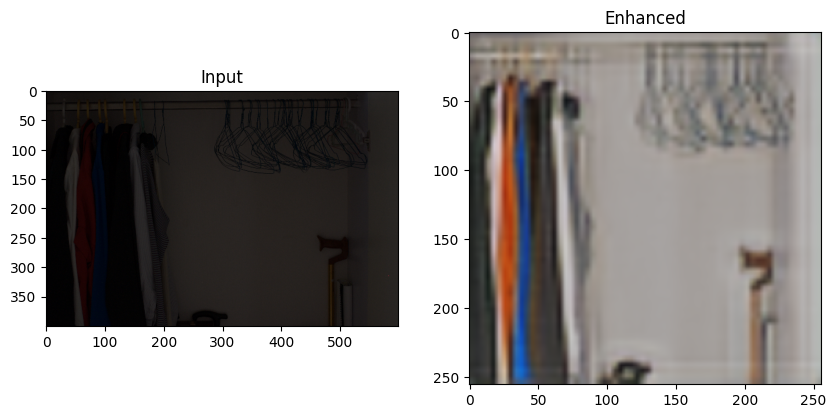

In [ ]:
import torch
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt


# ======================================================
# Load Trained Model
# ======================================================

model = LAN()

model.load_state_dict(
    torch.load('lan_model.pth',
               map_location='cpu')
)

model.eval()


# ======================================================
# Image Transform
# ======================================================

transform = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.ToTensor()

])


# ======================================================
# Load Low-Light Image
# ======================================================

image_path = '/content/lol_dataset/eval15/low/146.png'

image = Image.open(image_path).convert('RGB')

input_tensor = transform(image)

input_tensor = input_tensor.unsqueeze(0)


# ======================================================
# Inference
# ======================================================

with torch.no_grad():

    output = model(input_tensor)

output = output.squeeze(0).permute(1, 2, 0).numpy()


# ======================================================
# Display Result
# ======================================================

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Input")
plt.imshow(image)

plt.subplot(1,2,2)
plt.title("Enhanced")
plt.imshow(output)

plt.show()